In [2]:
import numpy as np

In [8]:
a = np.arange(10)*np.ones((10, 10))
indices=np.where(a>1)
print(len(indices))
print(indices)

print(np.prod(indices[0].size))

2
(array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2,
       2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5,
       5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8,
       8, 8, 8, 8, 8, 8, 9, 9, 9, 9, 9, 9, 9, 9], dtype=int64), array([2, 3, 4, 5, 6, 7, 8, 9, 2, 3, 4, 5, 6, 7, 8, 9, 2, 3, 4, 5, 6, 7,
       8, 9, 2, 3, 4, 5, 6, 7, 8, 9, 2, 3, 4, 5, 6, 7, 8, 9, 2, 3, 4, 5,
       6, 7, 8, 9, 2, 3, 4, 5, 6, 7, 8, 9, 2, 3, 4, 5, 6, 7, 8, 9, 2, 3,
       4, 5, 6, 7, 8, 9, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int64))
80


In [3]:
def taper(x, start_idx, end_idx):
    N = end_idx-start_idx
    n = np.arange(end_idx-start_idx).reshape(1, N)
    x[:, start_idx:end_idx]=x[:, start_idx:end_idx]*(np.cos(n/N*np.pi)+1)/2
    x[:,end_idx:]=0
    return x

In [ ]:
import numpy as np
from np.start import PEAQ
import matplotlib.pyplot as plt
import scipy.signal as sig

ModuleNotFoundError: No module named 'MOVs'

(1, 109, 45)
(1, 1025, 109, 1)


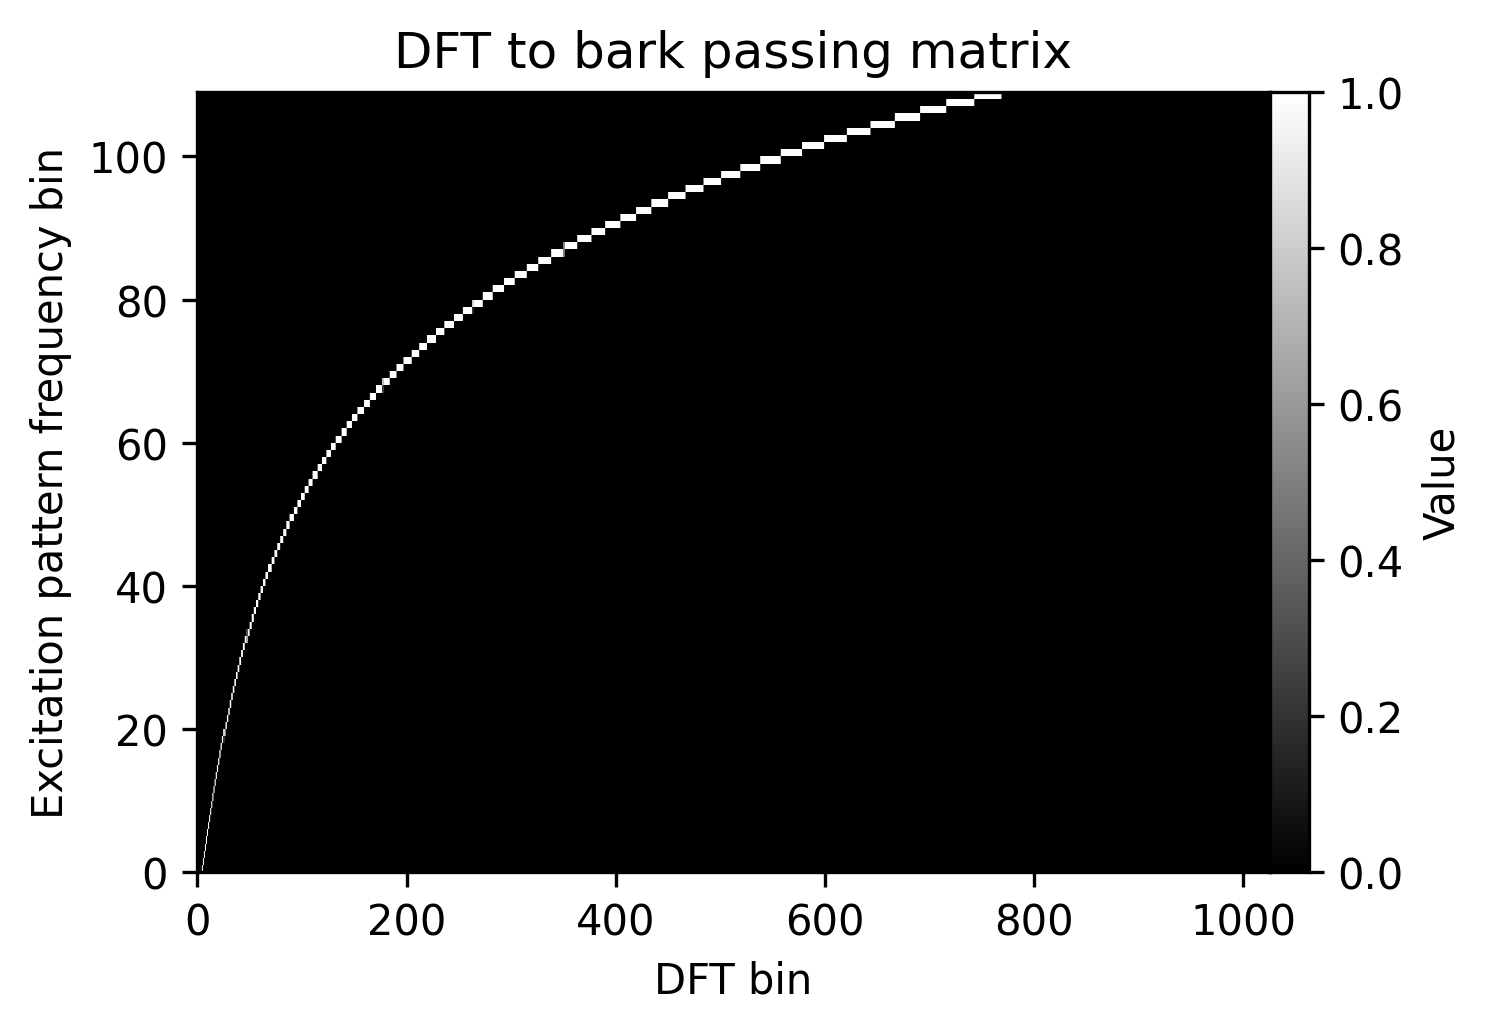

In [61]:
peaq = PEAQ_numpy()
n = np.arange(48000).reshape(1, -1)
sr_hz = 48000
f = 4000
x = np.sin(n*2*np.pi*f/sr_hz)/100000
x = taper(x, start_idx=5000, end_idx=5100)
#x[0,5000:]=0
#x = x*np.cos(n*2*np.pi*2/sr_hz)
Fss = sr_hz/1024

X = peaq.STFT(x)
E = peaq.timeToFrequencyDomain(x)
E = peaq.timeDomainSpreading(E, alpha=peaq.timeToFreqAlpha)
#E = np.zeros_like(E)
#E = E+peaq.internalNoise
#E = peaq.frequencySpreading(E)
print(E.shape)

cmap = plt.colormaps["gray"]
#plt.pcolormesh(
#    np.arange(E.shape[2])/Fss,
#    peaq.bandsCenter_hz[:,0],
#    peaq.dB10(E[0]), cmap=cmap, vmax=45, vmin=0)
##plt.semilogy()
#plt.ylabel('Bark bin')
#plt.xlabel('Time')
#plt.colorbar(label = 'Amplitude (dB)', pad=0)
#plt.tight_layout()
#plt.show()

print(peaq.barkBinGroupingMatrix.shape)
cm = 2.54
figsize = (13/cm, 9/cm)
plt.figure(figsize=figsize, dpi=300)
plt.pcolormesh(peaq.barkBinGroupingMatrix[0,:,:,0].T, cmap=cmap, vmin=0, vmax=1, rasterized=True)
plt.colorbar(label='Value', pad=0)
plt.xlabel('DFT bin')
plt.ylabel('Excitation pattern frequency bin')
#plt.semilogx()
#plt.xlim(1, 1024)
plt.title('DFT to bark passing matrix')
plt.tight_layout()
plt.savefig('Figures/passing_matrix.pdf', dpi=300)
plt.show()
#for i in range(peaq.numBarkBands):
#    plt.plot(peaq.f_hz, peaq.dB20(peaq.barkBinGroupingMatrix[0, :, i, 0]))
#plt.ylim(-30, 5)
#plt.xlim(0, 2000)
#plt.show()